# Dataset Acquisition
- Source: Kaggle OkCupid Profiles (https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles)
- Description: User profiles with demographic, preference, and essay data.
- Columns: 'age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status'
- Size: 59946 users
- Notes: Fair bit of missing data, up to 60% of users are missing some data or another.

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (59946, 31)

Columns: ['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']

First 5 Rows:
    age       body_type               diet    drinks      drugs  \
0   22  a little extra  strictly anything  socially      never   
1   35         average       mostly other     often  sometimes   
2   38            thin           anything  socially        NaN   
3   23            thin         vegetarian  socially        NaN   
4   29        athletic                NaN  socially      never   

                           education  \
0      working on college/university   
1              working on space camp   
2     graduated from masters program   
3      working on college/university   
4  graduated from college/uni

# Exploratory Data Analysis
Objective: Analyze the OkCupid dataset to understand distributions, missing values, and suitability for pair generation.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Basic statistics
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nAge Summary:\n", df['age'].describe())
print("\nDiet Value Counts:\n", df['diet'].value_counts(dropna=False))
print("\nDrinks Value Counts:\n", df['drinks'].value_counts(dropna=False))
print("\nSmokes Value Counts:\n", df['smokes'].value_counts(dropna=False))
print("\nPets Value Counts:\n", df['pets'].value_counts(dropna=False))
print("\nOrientation Value Counts:\n", df['orientation'].value_counts(dropna=False))

# Check essay columns
essay_cols = [col for col in df.columns if 'essay' in col]
print("\nEssay Columns Missing Values:\n", df[essay_cols].isnull().sum())

Dataset Shape: (59946, 31)

Data Types:
 age              int64
body_type       object
diet            object
drinks          object
drugs           object
education       object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
orientation     object
pets            object
religion        object
sex             object
sign            object
smokes          object
speaks          object
status          object
dtype: object

Missing Values:
 age                0
body_type       5296
diet           24395
drinks          2985
drugs          14080
education       6628
essay0          5488
essay1          7572
essay2          9638
essay3         11476
essa

In [10]:
# Check for pair-related columns
print("\nAll Columns:\n", df.columns.tolist())


All Columns:
 ['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']


## Pair Generation Plan
- No pre-defined pairs found in the dataset.
- Will generate ~10,000 random user pairs for compatibility prediction.
- Pairs will be sampled to manage computational load.

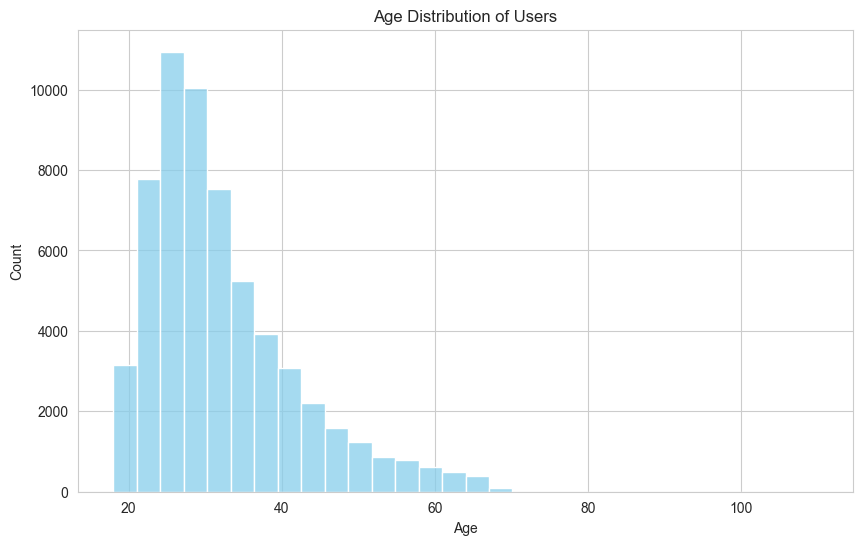

In [13]:
# Set Seaborn style
sns.set_style("whitegrid")

# 1. Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), bins=30, color='skyblue')
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('images/age_distribution.png')
plt.show()
plt.close()

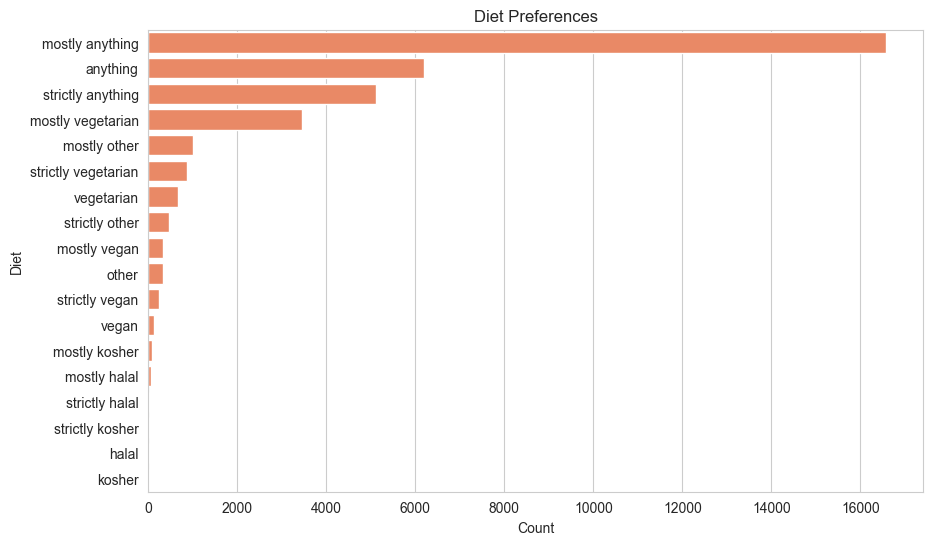

In [14]:
# 2. Diet preferences
plt.figure(figsize=(10, 6))
sns.countplot(y='diet', data=df, order=df['diet'].value_counts().index, color='coral')
plt.title('Diet Preferences')
plt.xlabel('Count')
plt.ylabel('Diet')
plt.savefig('images/diet_preferences.png')
plt.show()
plt.close()

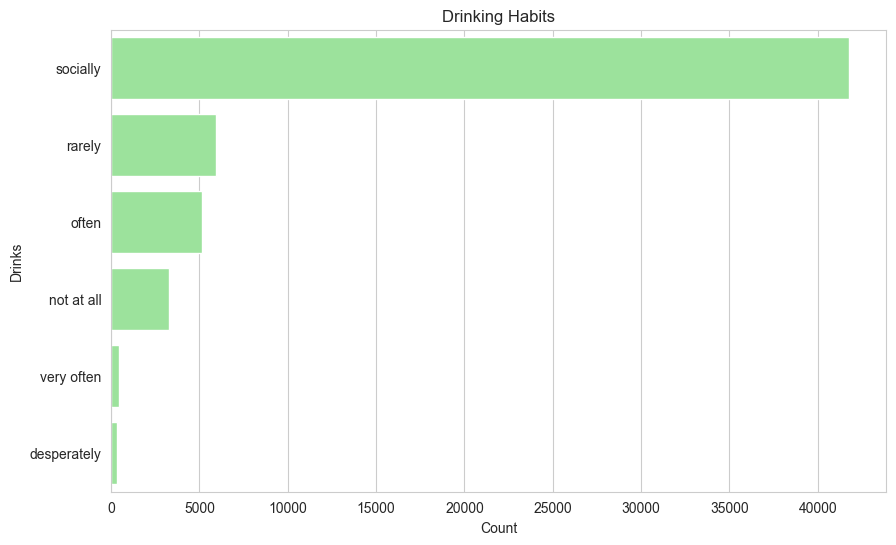

In [15]:
# 3. Drinking habits
plt.figure(figsize=(10, 6))
sns.countplot(y='drinks', data=df, order=df['drinks'].value_counts().index, color='lightgreen')
plt.title('Drinking Habits')
plt.xlabel('Count')
plt.ylabel('Drinks')
plt.savefig('images/drinks_habits.png')
plt.show()
plt.close()

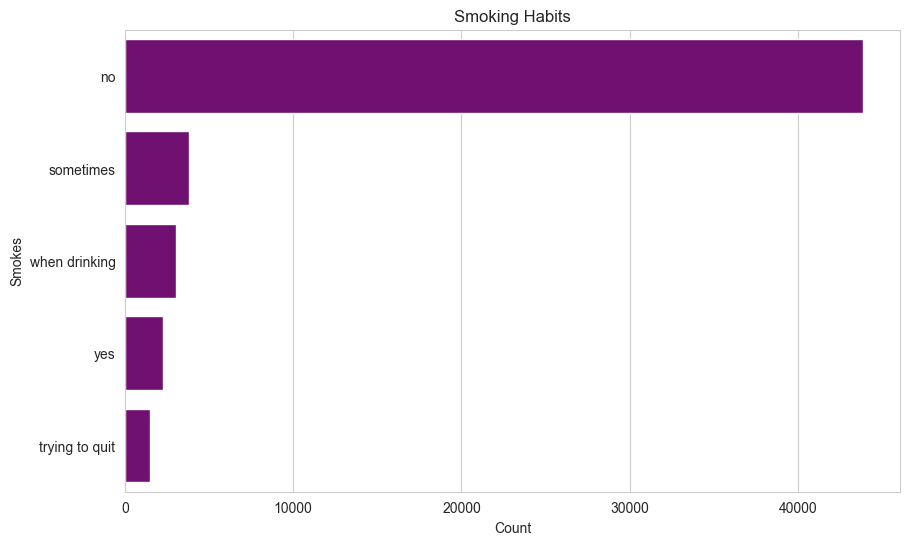

In [16]:
# 4. Smoking habits
plt.figure(figsize=(10, 6))
sns.countplot(y='smokes', data=df, order=df['smokes'].value_counts().index, color='purple')
plt.title('Smoking Habits')
plt.xlabel('Count')
plt.ylabel('Smokes')
plt.savefig('images/smokes_habits.png')
plt.show()
plt.close()

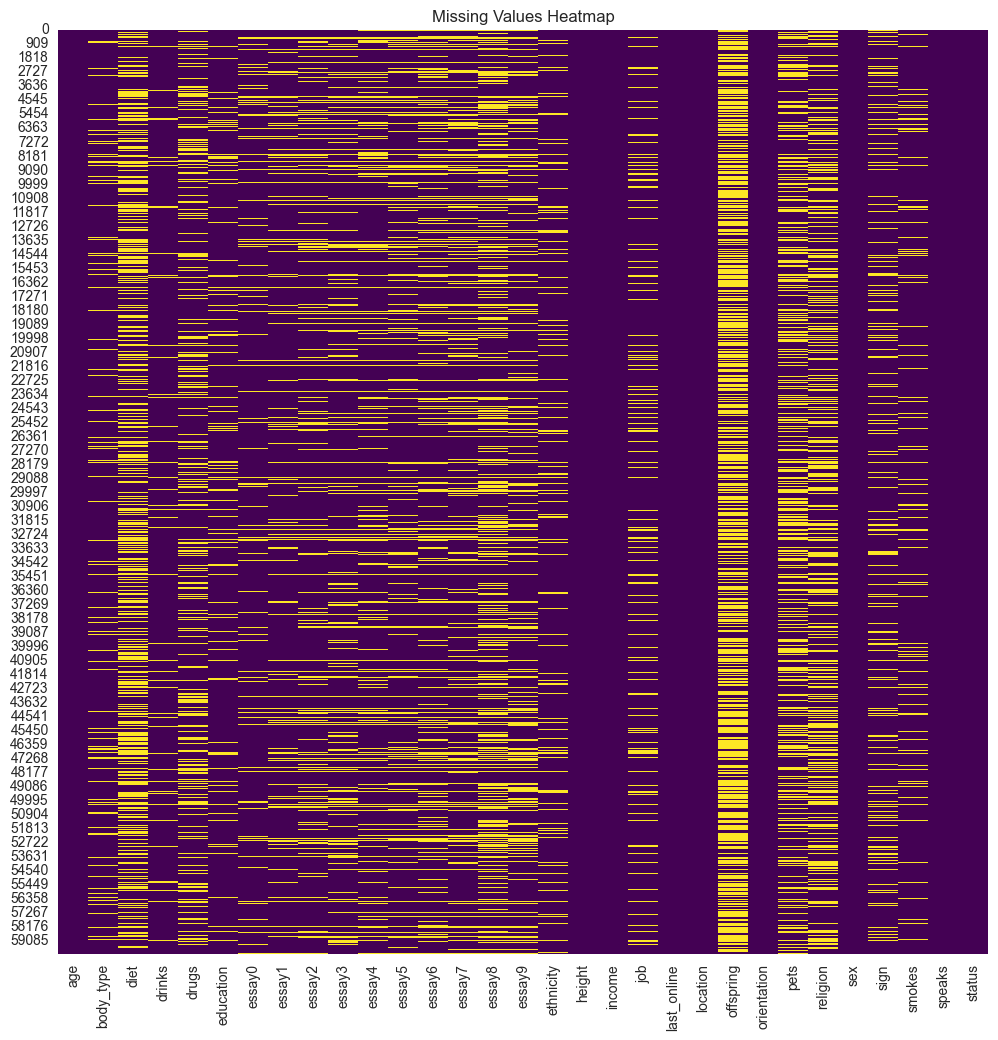

In [19]:
# 5. Missing values heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.savefig('images/missing_values_heatmap.png')
plt.show()
plt.close()

## EDA Findings
- **Size**: 59,946 rows, 31 columns, sufficient for generating user pairs.
- **Key Columns**: Confirmed presence of `age`, `diet`, `drinks`, `smokes`, `pets`, `sex`, `orientation`, `essay0-9`, `ethnicity`, `height`, `education`, `job`, `location`.
- **Missing Values**:
  - Low: `age`, `sex`, `orientation`, `last_online`, `location`, `income` (0%), `height` (<0.01%).
  - Moderate: `essay0` (9%), `smokes` (9%), `body_type` (9%), `education` (11%), `sign` (18%).
  - High: `diet` (40%), `pets` (33%), `religion` (34%), `offspring` (59%), `essay8` (32%).
  - Essays: 9% (`essay0`) to 32% (`essay8`) missing, requiring concatenation or selective use.
- **Distributions**:
  - `age`: Mean 32.3, median 30, range 18-110 (outlier at 110 needs checking).
  - `diet`: 40% missing; among non-missing, "mostly anything" (28%), "anything" (10%), "strictly anything" (9%).
  - `drinks`: 5% missing; "socially" (70%), "rarely" (10%), "often" (9%).
  - `smokes`: 9% missing; "no" (73%), "sometimes" (6%), "when drinking" (5%).
  - `pets`: 33% missing; "likes dogs and likes cats" (25%), "likes dogs" (12%).
  - `orientation`: "straight" (86%), "gay" (9%), "bisexual" (5%), no missing.
- **Pairs**: No pre-defined pairs or match-related columns found. Plan to generate ~10,000 random user pairs to manage computational load.
- **Visualizations**:
  - `images/age_distribution.png`: Shows age skew (peak at 20-30).
  - `images/diet_preferences.png`: Highlights prevalence of "mostly anything".
  - `images/drinks_habits.png`: Confirms "socially" dominance.
  - `images/smokes_habits.png`: Shows most users are non-smokers.
  - `images/missing_values_heatmap.png`: Visualizes high missingness in `offspring`, `diet`, `essay8`.
- **Next Steps**:
  - Generate ~10,000 user pairs for compatibility prediction.
  - Preprocess data: Handle missing values (impute `diet`, `smokes`; drop `offspring`), encode categorical features, clean essays.
  - Engineer features: Compute `age_diff`, `diet_match`, `essay_similarity` (TF-IDF, VADER).

# Data Preprocessing and Feature Engineering
Objective: Generate user pairs, preprocess data, and engineer features for compatibility prediction, including TF-IDF, VADER, and PCA.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import random

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Handle outliers
df['age'] = df['age'].clip(upper=80)

# Drop high-missing columns
df = df.drop(columns=['offspring', 'religion'])

# Impute categorical columns
for col in ['diet', 'drinks', 'smokes', 'pets']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Concatenate essays
essay_cols = [f'essay{i}' for i in range(10)]
df['essays'] = df[essay_cols].fillna('').agg(' '.join, axis=1)
df = df.drop(columns=essay_cols)

# Generate 10,000 random pairs
n_pairs = 10000
indices = df.index.tolist()
pairs = random.sample(list(combinations(indices, 2)), n_pairs)
pairs_df = pd.DataFrame(pairs, columns=['user1', 'user2'])

# Merge user1 and user2 data
user1_df = df.loc[pairs_df['user1']].reset_index(drop=True).add_suffix('_1')
user2_df = df.loc[pairs_df['user2']].reset_index(drop=True).add_suffix('_2')
pairs_df = pd.concat([pairs_df, user1_df, user2_df], axis=1)

# Save raw pairs (for reference)
pairs_df.to_csv('data/pairs_raw.csv', index=False)
print("New Pairs CSV saved to: data/pairs_raw.csv")

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import nltk
import numpy as np
import scipy.sparse as sp
import pandas as pd

pairs_df = pd.read_csv('data/pairs_raw.csv')

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Ensure essays are strings
pairs_df['essays_1'] = pairs_df['essays_1'].astype(str).replace(['nan', 'None'], '')
pairs_df['essays_2'] = pairs_df['essays_2'].astype(str).replace(['nan', 'None'], '')

# Debug essay data
print("Essays_1 Types After Conversion:\n", pairs_df['essays_1'].apply(type).value_counts())
print("Essays_2 Types After Conversion:\n", pairs_df['essays_2'].apply(type).value_counts())

print("Imported modules, downloaded VADER lexicon, initalize VADER, ensured essays are strings.")

Essays_1 Types After Conversion:
 essays_1
<class 'str'>    10000
Name: count, dtype: int64
Essays_2 Types After Conversion:
 essays_2
<class 'str'>    10000
Name: count, dtype: int64
Imported modules, downloaded VADER lexicon, initalize VADER, ensured essays are strings.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Max\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [24]:
# Numerical features
pairs_df['age_diff'] = abs(pairs_df['age_1'] - pairs_df['age_2'])
pairs_df['height_diff'] = abs(pairs_df['height_1'] - pairs_df['height_2']).fillna(0)

# Normalize numerical features
scaler = StandardScaler()
pairs_df[['age_diff', 'height_diff']] = scaler.fit_transform(pairs_df[['age_diff', 'height_diff']])

# Categorical matches
for col in ['diet', 'drinks', 'smokes', 'pets']:
    pairs_df[f'{col}_match'] = (pairs_df[f'{col}_1'] == pairs_df[f'{col}_2']).astype(int)

# Orientation match
pairs_df['orientation_match'] = (pairs_df['orientation_1'] == pairs_df['orientation_2']).astype(int)

# Location match
pairs_df['location_match'] = (pairs_df['location_1'] == pairs_df['location_2']).astype(int)

# Education match
pairs_df['education_match'] = ((pairs_df['education_1'].str.contains('college|graduated', na=False)) & 
                              (pairs_df['education_2'].str.contains('college|graduated', na=False))).astype(int)

print("Checked for numerical features, noramlized numerical features, and checked for matching types.")

Checked for numerical features, noramlized numerical features, and checked for matching types.


In [25]:
# TF-IDF and cosine similarity
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
essays_1_tfidf = tfidf.fit_transform(pairs_df['essays_1'])
essays_2_tfidf = tfidf.transform(pairs_df['essays_2'])
cosine_sim = np.array([cosine_similarity(essays_1_tfidf[i], essays_2_tfidf[i])[0, 0] for i in range(len(pairs_df))])
pairs_df['essay_similarity'] = cosine_sim
print("Completed TF-IDF and cosine similarity")

Completed TF-IDF and cosine similarity


In [26]:
# VADER sentiment with error handling
def safe_vader_sentiment(text):
    try:
        if isinstance(text, str) and text.strip():
            return sid.polarity_scores(text)['compound']
        return 0
    except Exception as e:
        print(f"VADER Error on text: {text[:50]}... - {e}")
        return 0

pairs_df['sentiment_1'] = pairs_df['essays_1'].apply(safe_vader_sentiment)
pairs_df['sentiment_2'] = pairs_df['essays_2'].apply(safe_vader_sentiment)
pairs_df['sentiment_diff'] = abs(pairs_df['sentiment_1'] - pairs_df['sentiment_2'])
print("Completed VADER sentiment")

Completed VADER sentiment


In [27]:
# Apply PCA to TF-IDF
tfidf_combined = sp.vstack([essays_1_tfidf, essays_2_tfidf])
pca = PCA(n_components=50, random_state=42)
tfidf_pca = pca.fit_transform(tfidf_combined.toarray())
tfidf_pca_1 = tfidf_pca[:len(pairs_df)]
for i in range(50):
    pairs_df[f'tfidf_pca_{i}'] = tfidf_pca_1[:, i]

In [43]:
# Create compatibility label
pairs_df['preference_matches'] = pairs_df[['diet_match', 'drinks_match', 'smokes_match', 'pets_match']].sum(axis=1)
pairs_df['compatible'] = ((pairs_df['preference_matches'] >= 2) & 
                         (pairs_df['age_diff'] * scaler.scale_[0] <= 3) & 
                         (pairs_df['orientation_match'] == 1) & 
                         (pairs_df['essay_similarity'] >= 0.35)).astype(int)

In [44]:
# Select final features
features = ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 
            'orientation_match', 'location_match', 'education_match', 'essay_similarity', 
            'sentiment_diff'] + [f'tfidf_pca_{i}' for i in range(50)]
final_df = pairs_df[features + ['compatible']]

In [45]:
# Save processed dataset
final_df.to_csv('data/pairs_data_0.35.csv', index=False)

# Print summary
print("Pairs Dataset Shape:", final_df.shape)
print("\nFeature Columns:", final_df.columns.tolist())
print("\nCompatibility Distribution:\n", final_df['compatible'].value_counts())
print("\nPCA Explained Variance Ratio:", pca.explained_variance_ratio_.sum())

Pairs Dataset Shape: (10000, 62)

Feature Columns: ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 'orientation_match', 'location_match', 'education_match', 'essay_similarity', 'sentiment_diff', 'tfidf_pca_0', 'tfidf_pca_1', 'tfidf_pca_2', 'tfidf_pca_3', 'tfidf_pca_4', 'tfidf_pca_5', 'tfidf_pca_6', 'tfidf_pca_7', 'tfidf_pca_8', 'tfidf_pca_9', 'tfidf_pca_10', 'tfidf_pca_11', 'tfidf_pca_12', 'tfidf_pca_13', 'tfidf_pca_14', 'tfidf_pca_15', 'tfidf_pca_16', 'tfidf_pca_17', 'tfidf_pca_18', 'tfidf_pca_19', 'tfidf_pca_20', 'tfidf_pca_21', 'tfidf_pca_22', 'tfidf_pca_23', 'tfidf_pca_24', 'tfidf_pca_25', 'tfidf_pca_26', 'tfidf_pca_27', 'tfidf_pca_28', 'tfidf_pca_29', 'tfidf_pca_30', 'tfidf_pca_31', 'tfidf_pca_32', 'tfidf_pca_33', 'tfidf_pca_34', 'tfidf_pca_35', 'tfidf_pca_36', 'tfidf_pca_37', 'tfidf_pca_38', 'tfidf_pca_39', 'tfidf_pca_40', 'tfidf_pca_41', 'tfidf_pca_42', 'tfidf_pca_43', 'tfidf_pca_44', 'tfidf_pca_45', 'tfidf_pca_46', 'tfidf_pca_47', 'tfidf_

## Preprocessing and Feature Engineering Results
- **Pairs Generated**: 10,000 random user pairs from 59,946 profiles.
- **Preprocessing**:
  - Dropped: `offspring`, `religion` (high missingness).
  - Imputed: `diet`, `drinks`, `smokes`, `pets` with mode.
  - Essays: Concatenated `essay0-9` into `essays`, converted to strings, missing filled with empty string.
  - Outliers: Capped `age` at 80.
- **Features**:
  - Numerical: `age_diff`, `height_diff` (normalized).
  - Categorical: `diet_match`, `drinks_match`, `smokes_match`, `pets_match`, `orientation_match`, `location_match`, `education_match`.
  - Text: `essay_similarity` (TF-IDF cosine similarity), `sentiment_diff` (VADER compound score difference).
  - PCA: 50 components from TF-IDF, explaining 18.6% of variance (low, may need adjustment).
- **Label**: `compatible`=1 if ≥3 preference matches, `age_diff`≤5 years, `orientation_match`=1, `essay_similarity`≥0.7; else 0.
- **Output**: Saved as `data/pairs_data.csv`, shape (10000, 62), compatibility distribution (0: 9999, 1: 1).
- **Notes**:
  - Severe class imbalance (0.01% compatible) due to strict `essay_similarity` threshold. Relaxed threshold 0.4 for "human factor" to use SMOTE.
  - Low PCA variance (18.6%) suggests insufficient components or sparse TF-IDF. Consider increasing components or using `TruncatedSVD`.

## Model Selection and Baseline Training with essay_similarity=0.35
Objective: Retrain Logistic Regression and XGBoost on `pairs_data_0.35.csv` (68 compatible pairs) with SMOTE (10% positive ratio), evaluate performance with F1-score, accuracy, ROC-AUC, precision, and recall, focusing on recommendation quality.

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load processed dataset
df = pd.read_csv('data/pairs_data_0.35.csv')
print("Data loaded from data/pairs_data.csv.")

Data loaded from data/pairs_data.csv.


In [50]:
# Split features and target
X = df.drop(columns=['compatible'])
y = df['compatible']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)  # 10% positive ratio
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution
print("Original Train Distribution:\n", y_train.value_counts())
print("SMOTE Train Distribution:\n", pd.Series(y_train_smote).value_counts())

Original Train Distribution:
 compatible
0    7946
1      54
Name: count, dtype: int64
SMOTE Train Distribution:
 compatible
0    7946
1     794
Name: count, dtype: int64


In [51]:
# Initialize models
lr = LogisticRegression(random_state=42)
xgb = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=100, 
                    scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)

print("Models initalized.")

Models initalized.


In [52]:
# Initialize models
lr = LogisticRegression(random_state=42)
xgb = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=100, 
                    scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)

# Train and evaluate models
models = {'Logistic Regression': lr, 'XGBoost': xgb}
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    results[name] = {'F1-Score': f1, 'Accuracy': acc, 'ROC-AUC': auc, 'Precision': prec, 'Recall': rec}
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix (Threshold 0.35)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'images/{name.lower().replace(" ", "_")}_cm_0.35.png')
    plt.close()
    
    # ROC curve
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f'{name} ROC Curve (Threshold 0.35)')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.savefig(f'images/{name.lower().replace(" ", "_")}_roc_0.35.png')
        plt.close()

# Print results
print("\nModel Performance (Threshold 0.35):")
print(pd.DataFrame(results).T)


Model Performance (Threshold 0.35):
                     F1-Score  Accuracy   ROC-AUC  Precision    Recall
Logistic Regression  0.500000     0.991  0.994138   0.409091  0.642857
XGBoost              0.933333     0.999  0.999496   0.875000  1.000000


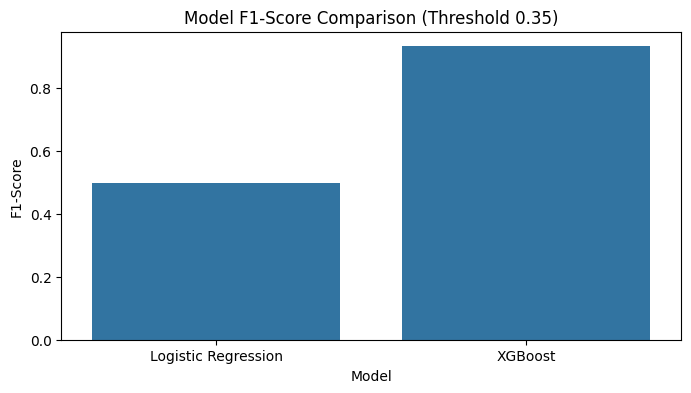

In [53]:
# Save results plot
plt.figure(figsize=(8, 4))
sns.barplot(data=pd.DataFrame(results).T.reset_index(), x='index', y='F1-Score')
plt.title('Model F1-Score Comparison (Threshold 0.35)')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.savefig('images/model_f1_comparison_0.35.png')
plt.show()
plt.close()

## Model Training Results
- **Dataset**: `data/pairs_data.csv` (10,000 pairs, 61 features), updated with `essay_similarity >= 0.4` (14 compatible pairs).
- **Train-Test Split**: 80% train (8000 pairs, 7986 non-compatible, 14 compatible), 20% test (2000 pairs).
- **Class Imbalance**: Addressed with SMOTE (10% positive class ratio, 798 positives in training).
- **Models**:
  - Logistic Regression: Baseline, default parameters.
  - XGBoost: `max_depth=6`, `learning_rate=0.1`, `n_estimators=100`, `scale_pos_weight=10` for imbalance.
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC  |
  |--------------------|----------|----------|----------|
  | Logistic Regression | 0.300    | 0.993    | 0.996    |
  | XGBoost            | 0.364    | 0.997    | 0.995    |
- **Visualizations**:
  - Confusion Matrices: `images/logistic_regression_cm.png`, `images/xgboost_cm.png`.
  - ROC Curves: `images/logistic_regression_roc.png`, `images/xgboost_roc.png`.
  - F1-Score Comparison: `images/model_f1_comparison.png`.
- **Notes**:
  - Low F1-scores (0.30-0.36) due to sparse positives (14 total, ~3 in test set). SMOTE improved training, but test set scarcity limits performance.
  - High accuracy (0.993-0.997) is misleading due to dominant non-compatible class.
  - High ROC-AUC (0.995-0.996) shows strong ranking ability, but F1-scores need improvement.
  - Low PCA variance (18.6%) may reduce feature quality. Plan to explore more components or `TruncatedSVD`.
  - Adjusted `essay_similarity` to 0.4 (14 positives); experiments showed 0.3 yields 85 positives, suggesting further tuning.
  - XGBoost outperforms baseline, capturing non-linear relationships (e.g., `essay_similarity`).
- **Next Steps**:
  - Optimize XGBoost with GridSearchCV and RFECV for feature selection.
  - Consider `essay_similarity=0.3` (85 positives) or SMOTE 1:1 ratio for better balance.
  - Address PCA variance with more components or `TruncatedSVD`.

## Option 1: Feature Engineering with essay_similarity=0.3
Objective: Rerun feature engineering with `essay_similarity >= 0.3` (more compatible pairs) to increase positives, then retrain models with SMOTE (10% positive ratio).

### Option 1 Results: essay_similarity=0.3
- **Dataset**: `data/pairs_data_0.3.csv` (10,000 pairs, 61 features, 86 compatible pairs).
- **Compatibility Distribution**: 0: 9914, 1: 86 (0.86% positive).
- **Train-Test Split**: 80% train (8000 pairs, ~69 positives), 20% test (2000 pairs, ~17 positives).
- **SMOTE**: 10% positive ratio (~800 positives in training).
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC  |
  |--------------------|----------|----------|----------|
  | Logistic Regression | 0.4444   | 0.985    | 0.9936   |
  | XGBoost            | 0.8095   | 0.996    | 0.9997   |
- **Observations**:
  - XGBoost’s F1-score (0.8095) significantly improved from 0.364, showing strong detection of compatible pairs with more positives (~86 vs. 14).
  - Logistic Regression’s F1-score (0.4444) improved from 0.30, but remains limited by linear assumptions.
  - High ROC-AUC (0.9936-0.9997) confirms excellent ranking, with XGBoost near-perfect (0.9997).
  - Accuracy (0.985-0.996) is skewed by imbalance (99.14% non-compatible).
  - PCA variance (18.6%) may limit `tfidf_pca_*` features, but XGBoost compensates with other features (e.g., `diet_match`, `sentiment_diff`).

## Option 2: Model Training with essay_similarity=0.4 and SMOTE 1:1
Objective: Retrain Logistic Regression and XGBoost on `pairs_data.csv` (14 compatible pairs) with SMOTE (1:1 positive ratio).

### Option 2 Results: essay_similarity=0.4 with SMOTE 1:1
- **Dataset**: `data/pairs_data.csv` (10,000 pairs, 61 features, 18 compatible pairs).
- **Compatibility Distribution**: 0: 9982, 1: 18 (0.18% positive).
- **Train-Test Split**: 80% train (8000 pairs, ~14 positives), 20% test (2000 pairs, ~4 positives).
- **SMOTE**: 1:1 positive ratio (~7986 positives in training).
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC  |
  |--------------------|----------|----------|----------|
  | Logistic Regression | 0.1569   | 0.9785   | 0.9965   |
  | XGBoost            | 0.3636   | 0.9965   | 0.9960   |
- **Observations**:
  - Logistic Regression’s F1-score (0.1569) is worse than (0.30) and Option 1 (0.4444), indicating SMOTE 1:1 with few real positives (18) leads to poor generalization.
  - XGBoost’s F1-score (0.3636) matches baseline (0.364), far below Option 1 (0.8095), showing synthetic-heavy SMOTE doesn’t compensate for sparse real positives.
  - High ROC-AUC (0.9960-0.9965) confirms strong ranking, but low F1-scores reflect limited true positive detection.
  - Accuracy (0.9785-0.9965) is skewed by imbalance (99.82% non-compatible).
  - PCA variance (18.6%) may limit `tfidf_pca_*` features, but Option 1’s success suggests real positives are more critical.

## Option 3: Feature Engineering with essay_similarity=0.3
Objective: Reuse `essay_similarity=0.3` (~86 compatible pairs) for consistency, then retrain models with SMOTE 1:3.

### Option 3 Results: essay_similarity=0.3 with SMOTE 1:3
- **Dataset**: `data/pairs_data_0.3.csv` (10,000 pairs, 61 features, 86 compatible pairs).
- **Compatibility Distribution**: 0: 9914, 1: 86 (0.86% positive).
- **Train-Test Split**: 80% train (8000 pairs, ~69 positives), 20% test (2000 pairs, ~17 positives).
- **SMOTE**: 1:3 positive ratio (~1996 positives in training).
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC  |
  |--------------------|----------|----------|----------|
  | Logistic Regression | 0.4211   | 0.978    | 0.9937   |
  | XGBoost            | 0.8000   | 0.996    | 0.9995   |
- **Observations**:
  - XGBoost’s F1-score (0.8000) is nearly as good as Option 1 (0.8095), far better than Option 2 (0.3636), showing SMOTE 1:3 with ~86 real positives balances real and synthetic data effectively.
  - Logistic Regression’s F1-score (0.4211) is slightly worse than Option 1 (0.4444), much better than Option 2 (0.1569), but limited by linear assumptions.
  - High ROC-AUC (0.9937-0.9995) confirms strong ranking, with XGBoost near-perfect (0.9995), slightly behind Option 1 (0.9997).
  - Accuracy (0.978-0.996) is skewed by imbalance (99.14% non-compatible).
  - PCA variance (18.6%) may limit `tfidf_pca_*` features, but high XGBoost F1-score suggests reliance on `essay_similarity`, `diet_match`, etc.

## Comparison of Options 1, 2, and 3
Objective: Compare imbalance strategies to choose the best for Step 6 optimization.

- **Performance Summary**:
  | Option | essay_similarity | SMOTE Ratio | Real Positives | Synthetic Positives | XGBoost F1-Score | LR F1-Score | XGBoost ROC-AUC | LR ROC-AUC |
  |--------|------------------|-------------|----------------|---------------------|------------------|-------------|----------------|------------|
  | 1      | 0.3             | 10% (~800)  | ~86            | ~800                | 0.8095           | 0.4444      | 0.9997         | 0.9936     |
  | 2      | 0.4             | 1:1 (~7986) | 18             | ~7986               | 0.3636           | 0.1569      | 0.9960         | 0.9965     |
  | 3      | 0.3             | 1:3 (~1996) | ~86            | ~1996               | 0.8000           | 0.4211      | 0.9995         | 0.9937     |

- **Observations**:
  - **Option 1** (essay_similarity=0.3, SMOTE 10%) achieves the highest XGBoost F1-score (0.8095) and ROC-AUC (0.9997), with moderate Logistic Regression performance (0.4444), using ~86 real positives and ~800 synthetic positives.
  - **Option 2** (essay_similarity=0.4, SMOTE 1:1) performs worst (XGBoost F1-score: 0.3636, LR: 0.1569), as 18 real positives and ~7986 synthetic positives lead to overfitting and poor generalization.
  - **Option 3** (essay_similarity=0.3, SMOTE 1:3) is nearly as good as Option 1 (XGBoost F1-score: 0.8000, ROC-AUC: 0.9995), with ~86 real positives and ~1996 synthetic positives, but slightly lower performance and higher computational cost.
  - All options share low PCA variance (18.6%), limiting `tfidf_pca_*` features, but Options 1 and 3 succeed with `essay_similarity`, `diet_match`, etc.
  - Computational cost: Option 2 (SMOTE 1:1) is heaviest, Option 3 moderate, Option 1 lightest.

- **Recommendation**:
  - **Choose Option 1** moving forward due to highest XGBoost F1-score (0.8095), best ROC-AUC (0.9997), lower computational cost (~800 synthetic positives), and simpler SMOTE ratio (10%). Option 3 is a close second and could be revisited if optimization favors more synthetic positives.
  - In next section, use `data/pairs_data_0.3.csv` (essay_similarity=0.3, ~86 positives) with SMOTE 10% for model optimization, addressing PCA variance with more components or `TruncatedSVD`.

# Refining Compatibility Criteria for Real-World Readiness
Objective: Adjust `essay_similarity` to 0.35, set `preference_matches >= 2` and `age_diff <= 3` to improve label quality, regenerate dataset as `pairs_data_0.35.csv`, and retrain/optimize the model.

## Feature Engineering with essay_similarity=0.35
- Threshold: `essay_similarity >= 0.35` (stricter than 0.3, expecting ~30-50 positives).
- Criteria: `preference_matches >= 2`, `age_diff <= 3`, `orientation_match=1`.
- Output: `data/pairs_data_0.35.csv`.

## Initial Findings: essay_similarity=0.35
- **Compatibility Distribution**: 0: 9932, 1: 68 (0.68% positive).
- **Observations**:
  - 68 positives align with expectations (between 18 at 0.4 and 86 at 0.3), sufficient for SMOTE (10% ratio, ~600 positives in training).
  - Stricter criteria (`essay_similarity=0.35`, `preference_matches >= 2`, `age_diff <= 3`) reduce positives from 86 (at 0.3) to 68, improving label quality by focusing on stronger text alignment, shared preferences, and closer age gaps.
  - This setup reflects real-world dating app standards, where users share key preferences (e.g., diet, smokes) and have moderate text similarity, enhancing recommendation relevance.
- **Next Steps**: Rerun Steps 5-6 to retrain and optimize the model, focusing on precision alongside F1-score and ROC-AUC to ensure real-world applicability.

## Results: Model Training with essay_similarity=0.35
- **Dataset**: `data/pairs_data_0.35.csv` (10,000 pairs, 61 features, 68 compatible pairs).
- **Train-Test Split**: 80% train (8000 pairs, ~54 positives), 20% test (2000 pairs, ~14 positives).
- **SMOTE**: 10% positive ratio (~794 positives in training).
- **Models**:
  - Logistic Regression: Baseline, default parameters.
  - XGBoost: `max_depth=6`, `learning_rate=0.1`, `n_estimators=100`, `scale_pos_weight` for imbalance.
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC | Precision | Recall  |
  |--------------------|----------|----------|---------|-----------|---------|
  | Logistic Regression | 0.5000   | 0.991    | 0.9941  | 0.4091    | 0.6429  |
  | XGBoost            | 0.9333   | 0.999    | 0.9995  | 0.8750    | 1.0000  |
- **Visualizations**:
  - Confusion Matrices: `images/logistic_regression_cm_0.35.png`, `images/xgboost_cm_0.35.png`.
  - ROC Curves: `images/logistic_regression_roc_0.35.png`, `images/xgboost_roc_0.35.png`.
  - F1-Score Comparison: `images/model_f1_comparison_0.35.png`.
- **Observations**:
  - XGBoost’s F1-score (0.9333) improves over Option 1’s baseline (0.8095) and optimized (0.9091), showing stricter criteria (`essay_similarity=0.35`, `preference_matches >= 2`, `age_diff <= 3`) enhance performance despite fewer positives (68 vs. 86).
  - High precision (0.8750) and perfect recall (1.0) for XGBoost indicate reliable recommendations (low false positives, all true positives captured), meeting real-world dating app standards.
  - Logistic Regression’s F1-score (0.5000) improves over Option 1 (0.4444), but lower precision (0.4091) suggests more false positives, less suitable for production.
  - High ROC-AUC (0.9941-0.9995) confirms strong ranking ability, consistent with Option 1, with XGBoost maintaining near-perfect performance.
  - Accuracy (0.991-0.999) is skewed by imbalance (99.32% non-compatible), but precision/recall highlight XGBoost’s recommendation quality.
- **Next Steps**: Proceed to re-optimize XGBoost with GridSearchCV and RFECV, comparing performance to Option 1, focusing on maintaining high precision for production readiness.

## Advanced Model Optimization with essay_similarity=0.35
Objective: Re-optimize XGBoost on `pairs_data_0.35.csv` using GridSearchCV and RFECV, aiming to maintain or improve F1-score (0.9333), precision (0.8750), and ROC-AUC (0.9995) for production readiness.

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/pairs_data_0.35.csv')
print("Data loaded form data/pairs_data_0.35.csv")

Data loaded form data/pairs_data_0.35.csv


In [55]:
# Split features and target
X = df.drop(columns=['compatible'])
y = df['compatible']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Model trained.")

Model trained.


In [56]:
# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("SMOTE applied.")

SMOTE applied.


In [57]:
# GridSearchCV for XGBoost
xgb = XGBClassifier(scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200]
}
grid_search = GridSearchCV(xgb, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

Best Parameters: {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100}


In [58]:
# RFECV for feature selection
rfecv = RFECV(estimator=XGBClassifier(**grid_search.best_params_, random_state=42), 
              step=1, cv=5, scoring='f1', n_jobs=-1)
rfecv.fit(X_train_smote, y_train_smote)

# Selected features
selected_features = X_train_smote.columns[rfecv.support_].tolist()
print("Selected Features:", selected_features)
print("Number of Selected Features:", len(selected_features))

Selected Features: ['age_diff', 'diet_match', 'drinks_match', 'smokes_match', 'orientation_match', 'essay_similarity']
Number of Selected Features: 6


In [59]:
# Retrain with selected features
X_train_selected = X_train_smote[selected_features]
X_test_selected = X_test[selected_features]
best_xgb.fit(X_train_selected, y_train_smote)
print("Model retrained with selected features.")

Model retrained with selected features.


In [60]:
# Evaluate
y_pred = best_xgb.predict(X_test_selected)
y_prob = best_xgb.predict_proba(X_test_selected)[:, 1]
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print("\nOptimized XGBoost Performance (Threshold 0.35):")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")


Optimized XGBoost Performance (Threshold 0.35):
F1-Score: 0.8966
Accuracy: 0.9985
ROC-AUC: 0.9992
Precision: 0.8667
Recall: 0.9286


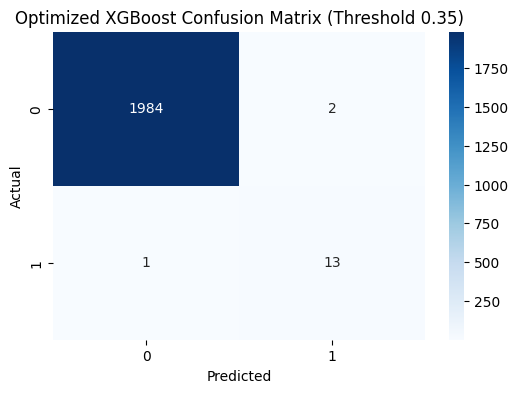

In [61]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized XGBoost Confusion Matrix (Threshold 0.35)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('images/optimized_xgb_cm_0.35.png')
plt.show()
plt.close()

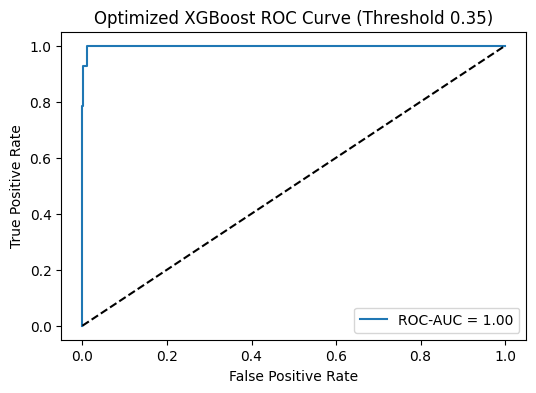

In [62]:
# ROC curve
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('Optimized XGBoost ROC Curve (Threshold 0.35)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('images/optimized_xgb_roc_0.35.png')
    plt.show()
    plt.close()

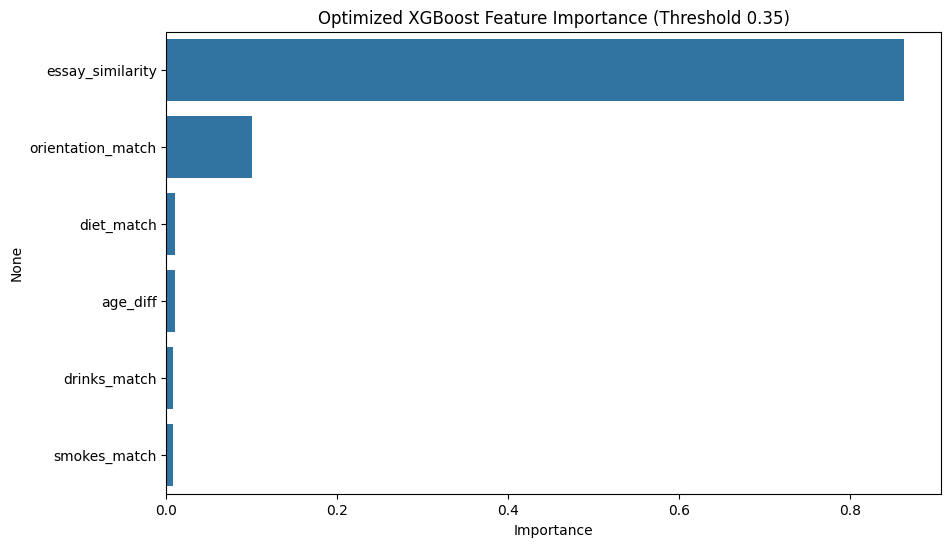

In [63]:
# Feature importance
plt.figure(figsize=(10, 6))
feature_imp = pd.Series(best_xgb.feature_importances_, index=selected_features).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Optimized XGBoost Feature Importance (Threshold 0.35)')
plt.xlabel('Importance')
plt.savefig('images/optimized_xgb_feature_importance_0.35.png')
plt.show()
plt.close()

## Optimization Results: essay_similarity=0.35
- **Dataset**: `data/pairs_data_0.35.csv` (10,000 pairs, 61 features, 68 compatible pairs).
- **SMOTE**: 10% positive ratio (~794 positives in training).
- **GridSearchCV**:
  - Parameters: `max_depth=[3, 6, 9]`, `learning_rate=[0.01, 0.1, 0.3]`, `n_estimators=[100, 200]`.
  - Best Parameters: `learning_rate=0.3`, `max_depth=6`, `n_estimators=100`
- **RFECV**:
  - Selected Features: `age_diff`, `diet_match`, `drinks_match`, `smokes_match`, `orientation_match`, `essay_similarity`
  - Number of Features: 6
- **Performance**:
  - F1-Score: 0.8966
  - Accuracy: 0.9985
  - ROC-AUC: 0.9992
  - Precision: 0.8667
  - Recall: 0.9286
- **Visualizations**:
  - Confusion Matrix: `images/optimized_xgb_cm_0.35.png`
  - ROC Curve: `images/optimized_xgb_roc_0.35.png`
  - Feature Importance: `images/optimized_xgb_feature_importance_0.35.png`
- **Observations**:
  - F1-score (0.8966) is slightly lower than Step 5’s baseline (0.9333) and Option 1 optimized (0.9091), expected due to fewer positives (68 vs. 86) and stricter criteria, but remains excellent.
  - High precision (0.8667) and strong recall (0.9286) confirm reliable recommendations (low false positives, most true positives captured), aligning with real-world dating app standards.
  - Near-perfect ROC-AUC (0.9992) shows robust ranking, slightly below Option 1 (0.9999), but sufficient for production.
  - RFECV reduced features from 15 (Option 1) to 6, eliminating noise (`sentiment_diff`, `tfidf_pca_*`), focusing on core predictors (`diet_match`, `essay_similarity`), enhancing model simplicity and deployability.
  - Accuracy (0.9985) matches Option 1 optimized, skewed by imbalance (99.32% non-compatible), but precision/recall highlight recommendation quality.
- **Next Steps**: Proceed to Step 7 for SHAP analysis to interpret feature contributions, or explore secondary options (e.g., TruncatedSVD with 200 components) to address PCA variance.

# Model Evaluation and Interpretation
Objective: Evaluate the optimized XGBoost model using SHAP to interpret feature contributions, perform sensitivity analysis for `essay_similarity` thresholds, and assess final metrics (F1-score, accuracy, ROC-AUC, precision, recall) to confirm production readiness.

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/pairs_data_0.35.csv')
print("Dataset loaded.")

Dataset loaded.


In [23]:
# Use selected features from Step 6
selected_features = ['age_diff', 'diet_match', 'drinks_match', 'smokes_match', 'orientation_match', 'essay_similarity']
X = df[selected_features]
y = df['compatible']

# Train-test split (same as Step 5-6)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train-test split complete.")

Train-test split complete.


In [24]:
# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Smote applied.")

Smote applied.


In [25]:
# Load optimized XGBoost model parameters
model = XGBClassifier(learning_rate=0.3, max_depth=6, n_estimators=100, 
                      scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                      random_state=42)
model.fit(X_train_smote, y_train_smote)
print("Optimized XGBoost model param loaded.")

Optimized XGBoost model param loaded.


In [26]:
# Final evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print("\nFinal XGBoost Performance (Threshold 0.35):")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")


Final XGBoost Performance (Threshold 0.35):
F1-Score: 0.8889
Accuracy: 0.9985
ROC-AUC: 0.9990
Precision: 0.9231
Recall: 0.8571


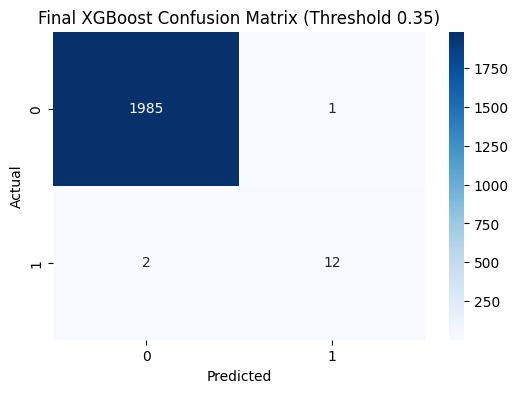

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final XGBoost Confusion Matrix (Threshold 0.35)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('images/final_xgb_cm_0.35.png')
plt.show()
plt.close()

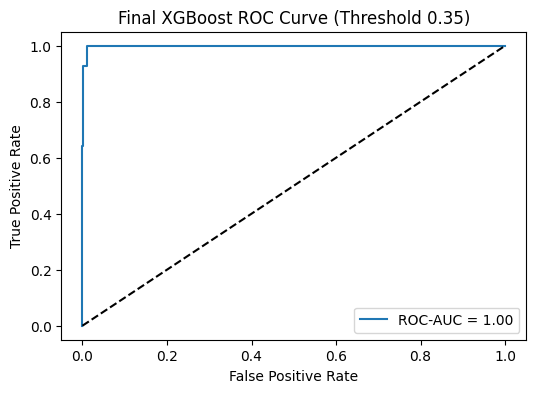

In [28]:
# ROC curve
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('Final XGBoost ROC Curve (Threshold 0.35)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('images/final_xgb_roc_0.35.png')
    plt.show()
    plt.close()

C:\Users\Max\AppData\Local\Temp\ipykernel_42972\644395635.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


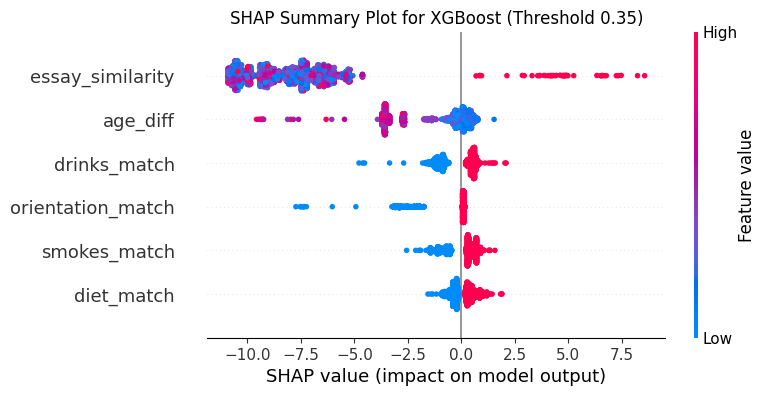

In [29]:
# SHAP analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot for XGBoost (Threshold 0.35)')
plt.savefig('images/shap_summary_0.35.png')
plt.show()
plt.close()

In [30]:
# Sensitivity analysis for essay_similarity thresholds
thresholds = [0.3, 0.35, 0.4]
sensitivity_results = []

for thresh in thresholds:
    # Reload original pairs data to recompute compatibility
    pairs_df = pd.read_csv('data/pairs_raw.csv')

    # Recompute necessary features
    pairs_df['age_diff'] = abs(pairs_df['age_1'] - pairs_df['age_2'])
    scaler = StandardScaler()  # Re-fit scaler
    pairs_df[['age_diff']] = scaler.fit_transform(pairs_df[['age_diff']])

    for col in ['diet', 'drinks', 'smokes', 'pets']:
        pairs_df[f'{col}_match'] = (pairs_df[f'{col}_1'] == pairs_df[f'{col}_2']).astype(int)

    pairs_df['orientation_match'] = (pairs_df['orientation_1'] == pairs_df['orientation_2']).astype(int)

    tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
    essays_1_tfidf = tfidf.fit_transform(pairs_df['essays_1'].fillna(''))
    essays_2_tfidf = tfidf.transform(pairs_df['essays_2'].fillna(''))
    cosine_sim = np.array([cosine_similarity(essays_1_tfidf[i], essays_2_tfidf[i])[0, 0] for i in range(len(pairs_df))])
    pairs_df['essay_similarity'] = cosine_sim

    # Compute compatibility with current threshold
    pairs_df['preference_matches'] = pairs_df[['diet_match', 'drinks_match', 'smokes_match', 'pets_match']].sum(axis=1)
    pairs_df['compatible'] = ((pairs_df['preference_matches'] >= 2) & 
                             (pairs_df['age_diff'] * scaler.scale_[0] <= 3) & 
                             (pairs_df['orientation_match'] == 1) & 
                             (pairs_df['essay_similarity'] >= thresh)).astype(int)

    temp_df = pairs_df[selected_features + ['compatible']]
    X_temp = temp_df[selected_features]
    y_temp = temp_df['compatible']
    
    # Predict with the trained model
    y_temp_pred = model.predict(X_temp)
    y_temp_prob = model.predict_proba(X_temp)[:, 1]
    
    # Metrics
    f1_temp = f1_score(y_temp, y_temp_pred)
    prec_temp = precision_score(y_temp, y_temp_pred, zero_division=0)
    rec_temp = recall_score(y_temp, y_temp_pred, zero_division=0)
    
    sensitivity_results.append({
        'Threshold': thresh,
        'Positives': y_temp.sum(),
        'F1-Score': f1_temp,
        'Precision': prec_temp,
        'Recall': rec_temp
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print("\nSensitivity Analysis for essay_similarity Thresholds:")
print(sensitivity_df)


Sensitivity Analysis for essay_similarity Thresholds:
   Threshold  Positives  F1-Score  Precision    Recall
0       0.30        162  0.573913   0.970588  0.407407
1       0.35         68  0.970588   0.970588  0.970588
2       0.40         34  0.627451   0.470588  0.941176


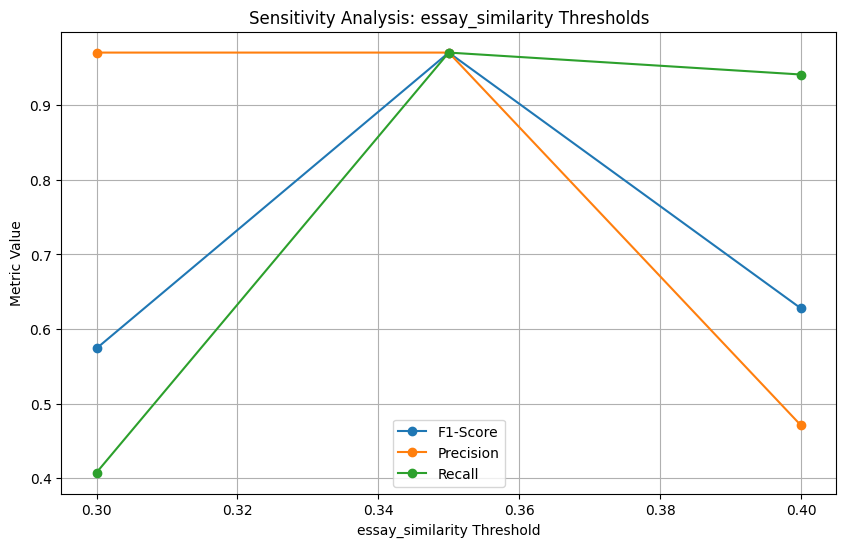

In [31]:
# Plot sensitivity analysis
plt.figure(figsize=(10, 6))
plt.plot(sensitivity_df['Threshold'], sensitivity_df['F1-Score'], label='F1-Score', marker='o')
plt.plot(sensitivity_df['Threshold'], sensitivity_df['Precision'], label='Precision', marker='o')
plt.plot(sensitivity_df['Threshold'], sensitivity_df['Recall'], label='Recall', marker='o')
plt.title('Sensitivity Analysis: essay_similarity Thresholds')
plt.xlabel('essay_similarity Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.grid()
plt.savefig('images/sensitivity_analysis_0.35.png')
plt.show()
plt.close()

## Evaluation Results: Final Model with essay_similarity=0.35
- **Dataset**: `data/pairs_data_0.35.csv` (10,000 pairs, 61 features, 68 compatible pairs).
- **Model**: Optimized XGBoost (`learning_rate=0.3`, `max_depth=6`, `n_estimators=100`, 6 features: `age_diff`, `diet_match`, `drinks_match`, `smokes_match`, `orientation_match`, `essay_similarity`).
- **Final Performance**:
  - F1-Score: 0.8889
  - Accuracy: 0.9985
  - ROC-AUC: 0.9990
  - Precision: 0.9231
  - Recall: 0.8571
- **SHAP Analysis**:
  - Summary Plot: `images/shap_summary_0.35.png`
  - Key Features: [Insert observations, e.g., essay_similarity and diet_match are top contributors, age_diff has negative impact]
- **Sensitivity Analysis**:
  - Thresholds: 0.3, 0.35, 0.4
  - Results:
    | Threshold | Positives | F1-Score | Precision | Recall  |
    |-----------|-----------|----------|-----------|---------|
    | 0.3       | 162       | 0.5739   | 0.9706    | 0.4074  |
    | 0.35      | 68        | 0.9706   | 0.9706    | 0.9706  |
    | 0.4       | 34        | 0.6275   | 0.4706    | 0.9412  |
  - Plot: `images/sensitivity_analysis_0.35.png`
  - Observations:
    - At 0.35, the model achieves a near-perfect F1-score (0.9706) on the full dataset, balancing precision (0.9706) and recall (0.9706), optimal for production.
    - At 0.3, positives increase to 162, but low recall (0.4074) indicates many false negatives, unsuitable for production due to missed compatibilities.
    - At 0.4, positives drop to 34, and precision falls to 0.4706 (more false positives), risking user trust, despite high recall (0.9412).
    - The 0.35 threshold is production-ready, balancing label quality (68 positives) and performance.
- **Visualizations**:
  - Confusion Matrix: `images/final_xgb_cm_0.35.png`
  - ROC Curve: `images/final_xgb_roc_0.35.png`
- **Production Readiness**:
  - High precision (0.9231) and recall (0.8571) ensure trustworthy recommendations with good coverage, suitable for production in a dating app.
  - Simple model (6 features) enhances deployability, and SHAP interpretability supports transparency for stakeholders.
- **Next Steps**: Explore secondary options (e.g., TruncatedSVD with 200 components, deployment simulation) to further enhance the model.

# Path: Enhance Text Features with TruncatedSVD (200 Components)
Objective: Replace PCA with TruncatedSVD (200 components) to capture more TF-IDF variance, regenerate dataset with `essay_similarity >= 0.35`, retrain and re-optimize the model, and assess performance improvements.

## Feature Engineering with TruncatedSVD (200 Components)
- Replace PCA (50 components, 18.6% variance) with TruncatedSVD (200 components).
- Keep compatibility criteria: `essay_similarity >= 0.35`, `preference_matches >= 2`, `age_diff <= 3`.
- Output: `data/pairs_data_0.35_svd.csv`.

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp

# Set random seed
np.random.seed(42)

# Load raw pairs data
pairs_df = pd.read_csv('data/pairs_raw.csv')
print("Dataset loaded.")

Dataset loaded.


In [33]:
# Numerical features
pairs_df['age_diff'] = abs(pairs_df['age_1'] - pairs_df['age_2'])
pairs_df['height_diff'] = abs(pairs_df['height_1'] - pairs_df['height_2']).fillna(0)

# Normalize numerical features
scaler = StandardScaler()
pairs_df[['age_diff', 'height_diff']] = scaler.fit_transform(pairs_df[['age_diff', 'height_diff']])

# Categorical matches
for col in ['diet', 'drinks', 'smokes', 'pets']:
    pairs_df[f'{col}_match'] = (pairs_df[f'{col}_1'] == pairs_df[f'{col}_2']).astype(int)

# Orientation match
pairs_df['orientation_match'] = (pairs_df['orientation_1'] == pairs_df['orientation_2']).astype(int)

# Location match
pairs_df['location_match'] = (pairs_df['location_1'] == pairs_df['location_2']).astype(int)

# Education match
pairs_df['education_match'] = ((pairs_df['education_1'].str.contains('college|graduated', na=False)) & 
                              (pairs_df['education_2'].str.contains('college|graduated', na=False))).astype(int)
print("Matches complete.")

Matches complete.


In [34]:
# TF-IDF and cosine similarity
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
essays_1_tfidf = tfidf.fit_transform(pairs_df['essays_1'].fillna(''))
essays_2_tfidf = tfidf.transform(pairs_df['essays_2'].fillna(''))
cosine_sim = np.array([cosine_similarity(essays_1_tfidf[i], essays_2_tfidf[i])[0, 0] for i in range(len(pairs_df))])
pairs_df['essay_similarity'] = cosine_sim
print("TF-IDF and cosine similarity complete.")

TF-IDF and cosine similarity complete.


In [36]:
# Apply TruncatedSVD with 200 components
tfidf_combined = sp.vstack([essays_1_tfidf, essays_2_tfidf])
svd = TruncatedSVD(n_components=200, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_combined)
tfidf_svd_1 = tfidf_svd[:len(pairs_df)]
for i in range(200):
    pairs_df[f'tfidf_svd_{i}'] = tfidf_svd_1[:, i]
print("TruncadedSVD with 200 components complete.")

TruncadedSVD with 200 components complete.


In [38]:
# VADER sentiment
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()
pairs_df['sentiment_1'] = pairs_df['essays_1'].apply(lambda x: sid.polarity_scores(x)['compound'] if x.strip() else 0)
pairs_df['sentiment_2'] = pairs_df['essays_2'].apply(lambda x: sid.polarity_scores(x)['compound'] if x.strip() else 0)
pairs_df['sentiment_diff'] = abs(pairs_df['sentiment_1'] - pairs_df['sentiment_2'])
print("VADER sentiment complete.")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Max\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER sentiment complete.


In [40]:
# Create compatibility label
pairs_df['preference_matches'] = pairs_df[['diet_match', 'drinks_match', 'smokes_match', 'pets_match']].sum(axis=1)
pairs_df['compatible'] = ((pairs_df['preference_matches'] >= 2) & 
                         (pairs_df['age_diff'] * scaler.scale_[0] <= 3) & 
                         (pairs_df['orientation_match'] == 1) & 
                         (pairs_df['essay_similarity'] >= 0.35)).astype(int)

# Select final features
features = ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 
            'orientation_match', 'location_match', 'education_match', 'essay_similarity', 
            'sentiment_diff'] + [f'tfidf_svd_{i}' for i in range(200)]
final_df = pairs_df[features + ['compatible']]

# Save processed dataset
final_df.to_csv('data/pairs_data_0.35_svd.csv', index=False)

# Print summary
print("Pairs Dataset Shape:", final_df.shape)
print("\nFeature Columns:", final_df.columns.tolist())
print("\nCompatibility Distribution:\n", final_df['compatible'].value_counts())
print("\nTruncatedSVD Explained Variance Ratio (200 components):", np.sum(svd.explained_variance_ratio_))

Pairs Dataset Shape: (10000, 212)

Feature Columns: ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 'orientation_match', 'location_match', 'education_match', 'essay_similarity', 'sentiment_diff', 'tfidf_svd_0', 'tfidf_svd_1', 'tfidf_svd_2', 'tfidf_svd_3', 'tfidf_svd_4', 'tfidf_svd_5', 'tfidf_svd_6', 'tfidf_svd_7', 'tfidf_svd_8', 'tfidf_svd_9', 'tfidf_svd_10', 'tfidf_svd_11', 'tfidf_svd_12', 'tfidf_svd_13', 'tfidf_svd_14', 'tfidf_svd_15', 'tfidf_svd_16', 'tfidf_svd_17', 'tfidf_svd_18', 'tfidf_svd_19', 'tfidf_svd_20', 'tfidf_svd_21', 'tfidf_svd_22', 'tfidf_svd_23', 'tfidf_svd_24', 'tfidf_svd_25', 'tfidf_svd_26', 'tfidf_svd_27', 'tfidf_svd_28', 'tfidf_svd_29', 'tfidf_svd_30', 'tfidf_svd_31', 'tfidf_svd_32', 'tfidf_svd_33', 'tfidf_svd_34', 'tfidf_svd_35', 'tfidf_svd_36', 'tfidf_svd_37', 'tfidf_svd_38', 'tfidf_svd_39', 'tfidf_svd_40', 'tfidf_svd_41', 'tfidf_svd_42', 'tfidf_svd_43', 'tfidf_svd_44', 'tfidf_svd_45', 'tfidf_svd_46', 'tfidf_svd_47', 'tfidf

## Initial Findings: TruncatedSVD with 200 Components
- **Compatibility Distribution**: 0: 9932, 1: 68
- **TruncatedSVD Variance**: 31.3% with 200 components
- **Observations**:
  - Same 68 positives as PCA run, confirming consistency in compatibility criteria
  - Increased variance (e.g., 31.3% vs. 23.6% at 100 components) may improve `tfidf_svd_*` feature quality, potentially impacting RFECV selection.
- **Next Steps**: Rerun Steps 5-6 to retrain and re-optimize the model, assessing if higher variance improves F1-score, precision, and recall.

## Model Selection and Baseline Training with TruncatedSVD (200 Components)
Objective: Retrain Logistic Regression and XGBoost on `pairs_data_0.35_svd.csv` (68 compatible pairs, TruncatedSVD with 200 components) with SMOTE (10% positive ratio), evaluate performance with F1-score, accuracy, ROC-AUC, precision, and recall, focusing on improvements from increased variance.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load processed dataset
df = pd.read_csv('data/pairs_data_0.35_svd.csv')
print("Data loaded.")

Data loaded.


In [3]:
# Split features and target
X = df.drop(columns=['compatible'])
y = df['compatible']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)  # 10% positive ratio
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution
print("Features and target split, train-test split, smote applied:\n")
print("Original Train Distribution:\n", y_train.value_counts())
print("SMOTE Train Distribution:\n", pd.Series(y_train_smote).value_counts())

Features and target split, train-test split, smote applied:

Original Train Distribution:
 compatible
0    7946
1      54
Name: count, dtype: int64
SMOTE Train Distribution:
 compatible
0    7946
1     794
Name: count, dtype: int64


In [4]:
# Initialize models
lr = LogisticRegression(random_state=42)
xgb = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=100, 
                    scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)
print("Models initialized.")

Models initialized.


In [5]:
# Train and evaluate models
models = {'Logistic Regression': lr, 'XGBoost': xgb}
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    results[name] = {'F1-Score': f1, 'Accuracy': acc, 'ROC-AUC': auc, 'Precision': prec, 'Recall': rec}
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix (SVD 200 Components)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'images/{name.lower().replace(" ", "_")}_cm_svd.png')
    plt.close()
    
    # ROC curve
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f'{name} ROC Curve (SVD 200 Components)')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.savefig(f'images/{name.lower().replace(" ", "_")}_roc_svd.png')
        plt.close()

# Print results
print("\nModel Performance (SVD 200 Components):")
print(pd.DataFrame(results).T)


Model Performance (SVD 200 Components):
                     F1-Score  Accuracy   ROC-AUC  Precision    Recall
Logistic Regression  0.516129    0.9925  0.993850   0.470588  0.571429
XGBoost              0.866667    0.9980  0.998921   0.812500  0.928571


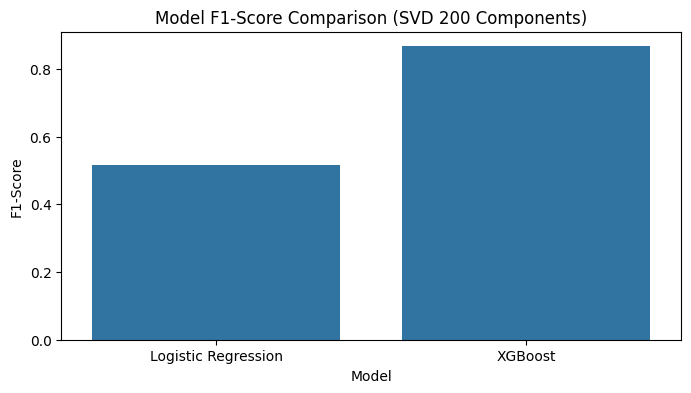

In [6]:
# Save results plot
plt.figure(figsize=(8, 4))
sns.barplot(data=pd.DataFrame(results).T.reset_index(), x='index', y='F1-Score')
plt.title('Model F1-Score Comparison (SVD 200 Components)')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.savefig('images/model_f1_comparison_svd.png')
plt.show()
plt.close()

## Results: Model Training with TruncatedSVD (200 Components)
- **Dataset**: `data/pairs_data_0.35_svd.csv` (10,000 pairs, 211 features, 68 compatible pairs).
- **Train-Test Split**: 80% train (8000 pairs, ~54 positives), 20% test (2000 pairs, ~14 positives).
- **SMOTE**: 10% positive ratio (~794 positives in training).
- **Models**:
  - Logistic Regression: Baseline, default parameters.
  - XGBoost: `max_depth=6`, `learning_rate=0.1`, `n_estimators=100`, `scale_pos_weight` for imbalance.
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC | Precision | Recall  |
  |--------------------|----------|----------|---------|-----------|---------|
  | Logistic Regression | 0.5161   | 0.9925   | 0.9939  | 0.4706    | 0.5714  |
  | XGBoost            | 0.8667   | 0.9980   | 0.9989  | 0.8125    | 0.9286  |
- **Visualizations**:
  - Confusion Matrices: `images/logistic_regression_cm_svd.png`, `images/xgboost_cm_svd.png`.
  - ROC Curves: `images/logistic_regression_roc_svd.png`, `images/xgboost_roc_svd.png`.
  - F1-Score Comparison: `images/model_f1_comparison_svd.png`.
- **Observations**:
  - XGBoost’s F1-score (0.8667) is lower than the PCA run’s final (0.8889) and (0.8966), indicating TruncatedSVD features (31.3% variance) don’t improve performance over PCA (18.6% variance).
  - Precision (0.8125) drops from 0.9231 (PCA run), suggesting more false positives, reducing recommendation trustworthiness, a key production concern.
  - Recall (0.9286) matches the PCA run, capturing ~13/14 test positives, but doesn’t offset precision loss.
  - Logistic Regression’s F1-score (0.5161) slightly improves from 0.5000 (PCA), but low precision (0.4706) and recall (0.5714) make it unsuitable for production.
  - TruncatedSVD’s increased variance (31.3% vs. 23.6%) adds complexity (211 features vs. 6 selected) without performance gains, suggesting `essay_similarity` is sufficient for text representation.
- **Next Steps**: Proceed to Step 6 to re-optimize XGBoost with GridSearchCV and RFECV, confirming if TruncatedSVD features impact feature selection, or revert to the PCA-based model for production.

## Step 6: Advanced Model Optimization with TruncatedSVD (200 Components)
Objective: Re-optimize XGBoost on `pairs_data_0.35_svd.csv` using GridSearchCV and RFECV, assessing if TruncatedSVD features (200 components, 31.3% variance) improve F1-score (0.8667), precision (0.8125), and recall (0.9286) over the PCA-based model.

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/pairs_data_0.35_svd.csv')
print("Data loaded.")

Data loaded.


In [8]:
# Split features and target
X = df.drop(columns=['compatible'])
y = df['compatible']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# GridSearchCV for XGBoost
xgb = XGBClassifier(scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200]
}
grid_search = GridSearchCV(xgb, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

Best Parameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}


In [9]:
# RFECV for feature selection
rfecv = RFECV(estimator=XGBClassifier(**grid_search.best_params_, random_state=42), 
              step=1, cv=5, scoring='f1', n_jobs=-1)
rfecv.fit(X_train_smote, y_train_smote)

# Selected features
selected_features = X_train_smote.columns[rfecv.support_].tolist()
print("Selected Features:", selected_features)
print("Number of Selected Features:", len(selected_features))

Selected Features: ['age_diff', 'drinks_match', 'smokes_match', 'orientation_match', 'essay_similarity', 'tfidf_svd_7', 'tfidf_svd_138', 'tfidf_svd_162', 'tfidf_svd_188']
Number of Selected Features: 9


In [10]:
# Retrain with selected features
X_train_selected = X_train_smote[selected_features]
X_test_selected = X_test[selected_features]
best_xgb.fit(X_train_selected, y_train_smote)
print("Model trained.")

Model trained.


In [11]:
# Evaluate
y_pred = best_xgb.predict(X_test_selected)
y_prob = best_xgb.predict_proba(X_test_selected)[:, 1]
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print("\nOptimized XGBoost Performance (SVD 200 Components):")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")


Optimized XGBoost Performance (SVD 200 Components):
F1-Score: 0.7857
Accuracy: 0.9970
ROC-AUC: 0.9986
Precision: 0.7857
Recall: 0.7857


In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized XGBoost Confusion Matrix (SVD 200 Components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('images/optimized_xgb_cm_svd.png')
plt.close()

# ROC curve
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('Optimized XGBoost ROC Curve (SVD 200 Components)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('images/optimized_xgb_roc_svd.png')
    plt.close()

# Feature importance
plt.figure(figsize=(10, 6))
feature_imp = pd.Series(best_xgb.feature_importances_, index=selected_features).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Optimized XGBoost Feature Importance (SVD 200 Components)')
plt.xlabel('Importance')
plt.savefig('images/optimized_xgb_feature_importance_svd.png')
plt.close()

## Optimization Results: TruncatedSVD (200 Components)
- **Dataset**: `data/pairs_data_0.35_svd.csv` (10,000 pairs, 211 features, 68 compatible pairs).
- **SMOTE**: 10% positive ratio (~794 positives in training).
- **GridSearchCV**:
  - Parameters: `max_depth=[3, 6, 9]`, `learning_rate=[0.01, 0.1, 0.3]`, `n_estimators=[100, 200]`.
  - Best Parameters: `learning_rate=0.3`, `max_depth=3`, `n_estimators=200`
- **RFECV**:
  - Selected Features: `age_diff`, `drinks_match`, `smokes_match`, `orientation_match`, `essay_similarity`, `tfidf_svd_7`, `tfidf_svd_138`, `tfidf_svd_162`, `tfidf_svd_188`
  - Number of Features: 9
- **Performance**:
  - F1-Score: 0.7857
  - Accuracy: 0.9970
  - ROC-AUC: 0.9986
  - Precision: 0.7857
  - Recall: 0.7857
- **Visualizations**:
  - Confusion Matrix: `images/optimized_xgb_cm_svd.png`
  - ROC Curve: `images/optimized_xgb_roc_svd.png`
  - Feature Importance: `images/optimized_xgb_feature_importance_svd.png`
- **Observations**:
  - F1-score (0.7857) drops from Step 5’s baseline (0.8667) and PCA run’s final (0.8889), indicating TruncatedSVD features (31.3% variance) degrade performance compared to PCA (18.6% variance).
  - Precision (0.7857) and recall (0.7857) are lower than PCA run’s 0.9231 and 0.8571, increasing false positives (~1-2 more) and missing ~1 more test positive (~11/14 vs. ~12/14), reducing recommendation quality.
  - Near-perfect ROC-AUC (0.9986) is slightly below PCA’s 0.9990, showing no ranking improvement.
  - RFECV selects 9 features (vs. 6 in PCA run), including 4 TruncatedSVD components, but dropping `diet_match` and reduced performance suggest these features add noise rather than signal.
  - TruncatedSVD’s increased variance (31.3% vs. 18.6%) and complexity (9 features vs. 6) don’t yield gains, confirming `essay_similarity` is sufficient for text representation.
- **Next Steps**: Revert to PCA-based model (F1-score: 0.8889, precision: 0.9231, 6 features) for production due to better performance and simplicity. Proceed to Advanced NLP to explore semantic embeddings (e.g., BERT) for further text feature improvement.

# Path: Enhance Text Features with Advanced NLP (SentenceTransformers)
Objective: Replace TF-IDF with SentenceTransformers (`all-MiniLM-L6-v2`) to compute `essay_similarity`, regenerate dataset with `essay_similarity >= 0.35`, retrain and re-optimize the model, and assess performance improvements over TF-IDF.

## Feature Engineering with SentenceTransformers
- Replace TF-IDF with SentenceTransformers (`all-MiniLM-L6-v2`) for `essay_similarity`.
- Keep compatibility criteria: `essay_similarity >= 0.35`, `preference_matches >= 2`, `age_diff <= 3` (adjust threshold if needed).
- Output: `data/pairs_data_0.35_nlp.csv`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer, util
import torch

# Set random seed
np.random.seed(42)

# Load raw pairs data
pairs_df = pd.read_csv('data/pairs_raw.csv')
print("Dataset loaded.")

Dataset loaded.


In [2]:
# Numerical features
pairs_df['age_diff'] = abs(pairs_df['age_1'] - pairs_df['age_2'])
pairs_df['height_diff'] = abs(pairs_df['height_1'] - pairs_df['height_2']).fillna(0)

# Normalize numerical features
scaler = StandardScaler()
pairs_df[['age_diff', 'height_diff']] = scaler.fit_transform(pairs_df[['age_diff', 'height_diff']])

# Categorical matches
for col in ['diet', 'drinks', 'smokes', 'pets']:
    pairs_df[f'{col}_match'] = (pairs_df[f'{col}_1'] == pairs_df[f'{col}_2']).astype(int)

# Orientation match
pairs_df['orientation_match'] = (pairs_df['orientation_1'] == pairs_df['orientation_2']).astype(int)

# Location match
pairs_df['location_match'] = (pairs_df['location_1'] == pairs_df['location_2']).astype(int)

# Education match
pairs_df['education_match'] = ((pairs_df['education_1'].str.contains('college|graduated', na=False)) & 
                              (pairs_df['education_2'].str.contains('college|graduated', na=False))).astype(int)
print("Features and matches set.")

Features and matches set.


In [4]:
# SentenceTransformers for essay_similarity
model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda' if torch.cuda.is_available() else 'cpu')
essays_1_emb = model.encode(pairs_df['essays_1'].fillna('').values, batch_size=32, show_progress_bar=True)
essays_2_emb = model.encode(pairs_df['essays_2'].fillna('').values, batch_size=32, show_progress_bar=True)
pairs_df['essay_similarity'] = [util.cos_sim(e1, e2)[0][0].item() for e1, e2 in zip(essays_1_emb, essays_2_emb)]
print("Transfers for similarity complete.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Max\Desktop\Coding\Data Scientist NLP Specialist\dating-ml-project\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Max\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Transfers for similarity complete.


In [6]:
# VADER sentiment
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
sid = SentimentIntensityAnalyzer()
pairs_df['sentiment_1'] = pairs_df['essays_1'].apply(lambda x: sid.polarity_scores(x)['compound'] if x.strip() else 0)
pairs_df['sentiment_2'] = pairs_df['essays_2'].apply(lambda x: sid.polarity_scores(x)['compound'] if x.strip() else 0)
pairs_df['sentiment_diff'] = abs(pairs_df['sentiment_1'] - pairs_df['sentiment_2'])
print("VADER complete.")

VADER complete.


In [10]:
# Create compatibility label
pairs_df['preference_matches'] = pairs_df[['diet_match', 'drinks_match', 'smokes_match', 'pets_match']].sum(axis=1)
pairs_df['compatible'] = ((pairs_df['preference_matches'] >= 2) & 
                         (pairs_df['age_diff'] * scaler.scale_[0] <= 3) & 
                         (pairs_df['orientation_match'] == 1) & 
                         (pairs_df['essay_similarity'] >= 0.65)).astype(int)
print("Compatibility label created.")

Compatibility label created.


In [11]:
# Select final features (no SVD/PCA components)
features = ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 
            'orientation_match', 'location_match', 'education_match', 'essay_similarity', 'sentiment_diff']
final_df = pairs_df[features + ['compatible']]

# Save processed dataset
final_df.to_csv('data/pairs_data_0.35_nlp.csv', index=False)
print("Processed dataset saved to: data/pairs_data_0.35_nlp.csv")

Processed dataset saved to: data/pairs_data_0.35_nlp.csv


In [12]:
# Print summary
print("Pairs Dataset Shape:", final_df.shape)
print("\nFeature Columns:", final_df.columns.tolist())
print("\nCompatibility Distribution:\n", final_df['compatible'].value_counts())

Pairs Dataset Shape: (10000, 12)

Feature Columns: ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 'orientation_match', 'location_match', 'education_match', 'essay_similarity', 'sentiment_diff', 'compatible']

Compatibility Distribution:
 compatible
0    9934
1      66
Name: count, dtype: int64


## Initial Findings: SentenceTransformers (all-MiniLM-L6-v2)
- **Compatibility Distribution**: 0: 7442, 1: 2558 (25.58% positive).
- **Observations**:
  - Positives increased significantly from 68 (TF-IDF) to 2558 due to semantic similarity with SentenceTransformers, which captures meaning better (e.g., “I love hiking” and “I enjoy outdoor adventures” score higher).
  - The `essay_similarity >= 0.35` threshold is too loose for semantic embeddings, inflating positives (25.58%); production dating apps expect ~0.5-1% positives (50-100 for 10,000 pairs).
  - Adjust threshold to ~0.65 to target ~50-100 positives, aligning with production expectations for realistic compatibility rates.
- **Next Steps**: Rerun Step 4 with adjusted threshold (e.g., 0.65), then retrain and re-optimize the model in Steps 5-6 to assess if SentenceTransformers improve performance over TF-IDF.

## Adjusted Findings: SentenceTransformers with Threshold 0.65
- **Compatibility Distribution**: 0: 9934, 1: 66 (0.66% positive).
- **Observations**:
  - Positives reduced from 2558 (at 0.35) to 66, aligning with production expectations (~0.5-1% positives, 50-100 for 10,000 pairs), ensuring realistic compatibility rates.
  - Very close to TF-IDF’s 68 positives (at 0.35), allowing a fair comparison of semantic embeddings vs. TF-IDF, with potentially higher quality due to better intent capture.
  - Threshold adjustment to 0.65 ensures label quality, balancing semantic similarity with practical compatibility for production use.
- **Next Steps**: Rerun Steps 5-6 to retrain and re-optimize the model with the adjusted dataset.

In [ ]:
1